In [ ]:
import tensorflow as tf
import numpy as np
from utils import get_model, draw_heatmap

EPOCHS = 10
IMG_WIDTH=30
IMG_HEIGHT=30

Demonstration of overfitting phenomena

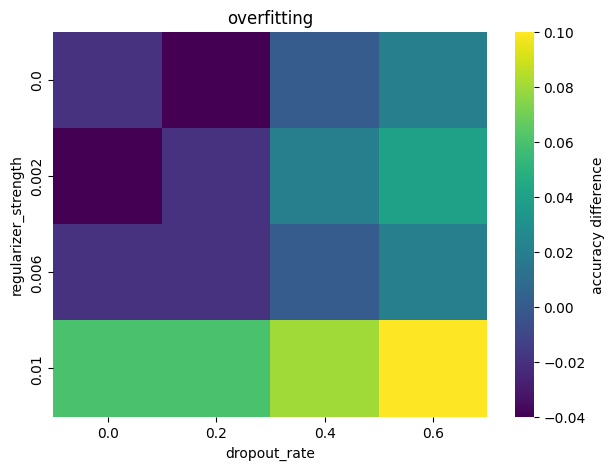

In [ ]:
train, val = np.load("train_processed.npz"), np.load("val_processed.npz")
X_train, y_train, X_val, y_val = train["X"], train["y"], val["X"], val["y"]


# one hot encoding
y_train = tf.keras.utils.to_categorical(y_train)
y_val = tf.keras.utils.to_categorical(y_val)

# a possible range of dropout_rates and regularizer_strengths for overfitting
dropout_rates=[0.0, 0.2, 0.4, 0.6]
regularizer_strengths=[0, 1e-4, 1e-3, 1e-2]
overfitting=[]

for dropout_rate in dropout_rates:
    for regularizer_strength in regularizer_strengths:        
        model = get_model(dropout_rate,regularizer_strength, batch_normalization=True, img_width=IMG_WIDTH, img_height=IMG_HEIGHT)

        history=model.fit(X_train, y_train, epochs=EPOCHS, batch_size=32, shuffle=False)

        # Evaluate neural network performance
        loss,val_accuracy=model.evaluate(X_val, y_val, verbose=2, batch_size=32)
        last_epoch_training_accuracy = history.history['accuracy'][-1]
        overfitting.append([dropout_rate,regularizer_strength,val_accuracy-last_epoch_training_accuracy])
draw_heatmap(overfitting, "overfitting")

The `accuracy difference` here is `val_accuracy`-`last_epoch_training_accuracy`. It indicates more severe overfitting when it goes down, and less severe overfitting when it goes up. As we increase the drop out rate or increase the regularization strength, there is less and less overfitting.

Demonstration of underfitting phenomena

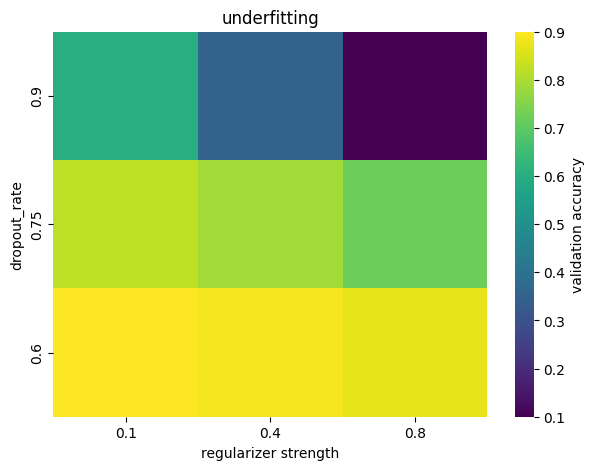

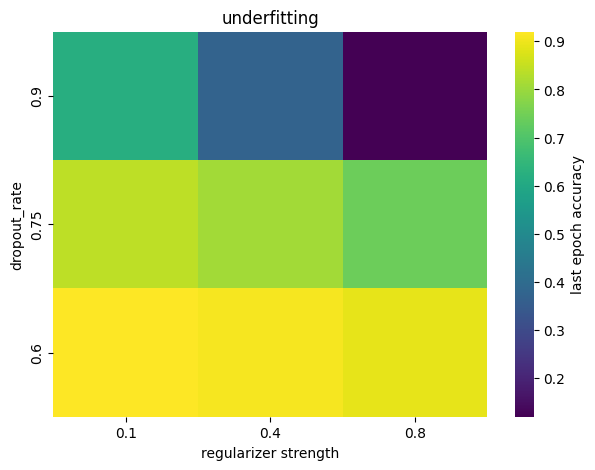

In [ ]:
train, val = np.load("train_processed.npz"), np.load("val_processed.npz")
X_train, y_train, X_val, y_val = train["X"], train["y"], val["X"], val["y"]


# one hot encoding
y_train = tf.keras.utils.to_categorical(y_train)
y_val = tf.keras.utils.to_categorical(y_val)

# a possible range of dropout_rates and regularizer_strengths for underfitting
dropout_rates= [0.4, 0.6, 0.8]
regularizer_strengths= [0.4, 0.6, 0.8]
underfitting1, underfitting2 = [], []

for dropout_rate in dropout_rates:
    for regularizer_strength in regularizer_strengths:        
        model = get_model(dropout_rate,regularizer_strength, batch_normalization=True, img_width=IMG_WIDTH, img_height=IMG_HEIGHT)
        
        history=model.fit(X_train, y_train, epochs=EPOCHS, batch_size=32, shuffle=False)
        
        loss,val_accuracy=model.evaluate(X_val, y_val, verbose=2, batch_size=32)
        last_epoch_training_accuracy = history.history['accuracy'][-1]
        underfitting1.append([dropout_rate,regularizer_strength,val_accuracy])
        underfitting2.append([dropout_rate,regularizer_strength,last_epoch_training_accuracy])
draw_heatmap(underfitting1, "underfitting")
draw_heatmap(underfitting2, "underfitting")


However, when the dropout rate and/or regularization strength are/is too large, underfitting happens. Both train and validation accuracy drop to a very low level.